In [2]:
import matplotlib.pyplot as plt
import numpy as np

# **Metodo agli Elementi Finiti (stazionario) - Parte 2**

## Condizioni di Neumann

Per problemi mono-dimensionali, definiti su un certo intervallo $[a,b]\subset\mathbb{R}$, una condizione al bordo della forma</br></br>
$$u'(b)=\gamma,$$

o, in alternativa, $u'(a)=\gamma$, è detta condizione di Neumann. Nei metodi agli elementi finiti, questo tipo di condizione viene tipicamente gestita includendo esplicitamente un termine di bordo nella formulazione variazionale. Ad esempio, si consideri il seguente problema con condizioni miste Dirichlet-Neumann,

$$\begin{cases}
-u'' = f, & \text{in}\;(a,b)\\\\
u(a)=\alpha,\;\;
u'(b)=\gamma.
\end{cases}$$

Posto $V_{\text{test}}:=\{v\in H^{1}(a,b)\;|\;v(a)=0\}$, la sua formulazione debole è

$$\int_a^b-u''vdx = \int_a^b fvdx, \quad\quad \forall v\in V_{\text{test}}\quad\rightsquigarrow\quad\int_a^bu'v'dx - \left[u'v\right]\Big |^{b}_{a}= \int_a^b fvdx, \quad\quad \forall v\in V_{\text{test}}$$

$$\rightsquigarrow\int_a^bu'v'dx = \int_a^b fvdx + \left[u'v\right]\Big |^{b}_{a},\quad\quad \forall v\in V_{\text{test}}$$

$$\rightsquigarrow\int_a^bu'v'dx = \int_a^b fvdx + \gamma v(b),\quad\quad \forall v\in V_{\text{test}}.$$

Il termine $\gamma v(b)$ produce quindi una modifica in corrispondenza dell'ultimo nodo della mesh, che va gestita opportunamente.

In [ ]:
#devo ricordare che il termine gamma*v(b) è legato al valore della funzione di base phi valutata in b!! L'unica modifica da fare
#per imporre la condizione di Neumann è: F[end]+=gamma -> l'ultimo nodo della matrice F (termine noto) si deve aggiungere l'elemento
#che raooresenta la condizione di Neumann

<mark>**Esercizio 1.1**</mark></br>

Si consideri il seguente problema differenziale

$$\begin{cases}
-u''=30x, & x\in(0,1)\\
u(0)=0,\\u'(1)=3.
\end{cases}$$

Risolvere il problema implementando il metodo agli elementi finiti (grado polinomiale $r=1$, passo della mesh $h=0.1$). Confrontare graficamente la soluzione ottenuta con la soluzione esatta, $u(x)=18x-5x^3.$

In [3]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.1
# bc di Neumann
gamma = 3

f=lambda x: 30*x

# generazione griglia
Nele=int((b-a)/h)
grid=Grid(a,b,Nele)
grid.compute_geometry()

# assemblaggio matrice di rigidezza
A=diffusion(grid)

# assemblaggio termine noto con condizioni di Neumann
M=mass(grid)
f_dofs=fun2dof(grid,f)
F=M @ f_dofs #assembla l'integrale di f*v in (a,b)

# Neumann al bordo destro
F[-1]+=gamma

# gestione condizioni di Dirichlet
dirichlet_nodes = [0]
dirichlet_values = [0]

# creazione vettore dei valori al bordo, inizializzato a zero
bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values

# costruzione matrice di restrizione R
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False #matrice di veri che diventa falsa in corrispondenza dei nori di Dirichlet

R = create_restriction(keep_dof)

# Restrizione di A e del termine noto
A0=R@A@R.T
F0=R@(F-A@bc_values) #F0 chiamato anche rhs_0

# risoluzione sistema lineare (soluzione ai nodi interni -> è la soluzione del problema ristretto)
u0=np.linalg.solve(A0, F0)

# aggiunta condizione di Dirichlet (R.T NON opera una restrizione ma un'aggiunta di una riga; vedi teoria)
u=bc_values+R.T@u0

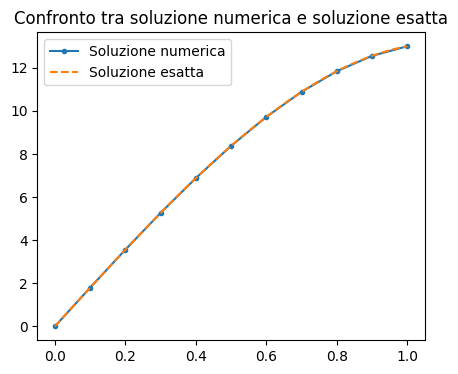

In [6]:
# rappresentazione grafica della soluzione numerica e confronto con soluzione esatta


# soluzione esatta
uex = lambda x: 18 * x - 5 * (x**3)
xplot = np.linspace(a, b, 1000)

plt.figure(figsize=(5, 4))
plt.plot(grid.nodes, u, marker=".", label="Soluzione numerica")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")

plt.title("Confronto tra soluzione numerica e soluzione esatta")
plt.legend()
plt.show()

In [ ]:
#la soluzione numerica è una spezzata costante a tratti che approssima e segue bene la soluzione esatta; ci si aspetta un ordine
#di converganza 2, come visto nella parte 1 del metodo agli elementi finiti

<mark>**Esercizio 1.2**</mark></br>

Ripetere l'Es. 1.1 invertendo le condizioni di Neumann e Dirichlet, cioè risolvendo

$$\begin{cases}
-u''=30x & x\in(0,1)\\
u'(0)=3\\u(1)=0,
\end{cases}$$

la cui soluzione esatta è $u(x)=3x-5x^3+2.$

In [8]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.1
# numero elementi
Nele = int((b - a) / h)
# creazione griglia
Nele=int((b-a)/h)
grid=Grid(a,b,Nele)
grid.compute_geometry()

# assemblaggio matrice di rigidezza
A=diffusion(grid)

# assemblaggio termine noto con condizioni di Neumann
f=lambda x: 30*x

M=mass(grid)
f_dofs=fun2dof(grid, f)
F=M@f_dofs
F[0]-=gamma

# gestione condizioni di Dirichlet
dirichlet_nodes = [-1] #oppure: dirichlet_nodes=[Nele]
dirichlet_values = [0]

bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False

R = create_restriction(keep_dof)
print(R)

A0 = R@A@R.T
F0 = R @ (F - A @ bc_values)

# risoluzione sistema lineare
u_0 = np.linalg.solve(A0,F0)

# aggiunta condizione di Dirichlet
u = bc_values+R.T@u_0

[[1 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0]]


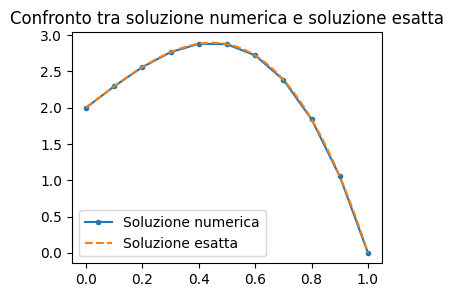

In [9]:
# rappresentazione grafica della soluzione numerica e confronto con soluzione esatta
# soluzione esatta
uex = lambda x: 3 * x - 5 * (x**3) + 2
xplot = np.linspace(a, b, 1000)


plt.figure(figsize=(4, 3))
plt.plot(grid.nodes, u, marker=".", label="Soluzione numerica")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")

plt.title("Confronto tra soluzione numerica e soluzione esatta")
plt.legend()
plt.show()

# Equazioni di diffusione-trasporto (esempio di trasporto dominante)

Si consideri il seguente problema differenziale, descrivente un fenomeno di diffusione-trasporto (stazionario)

$$
\begin{cases}
(-\alpha u'+\beta u)'= f, & x\in(0,1)\\
u(0)=0\\
u(1)=1.
\end{cases}
$$

dove $\alpha>0,\beta\neq0$ sono opportuni coefficienti. La corrispondente formulazione debole è
</br></br>
$$ \int_0^1 \alpha u'v'dx-\int_0^1\beta uv'dx=\int_0^1fvdx.$$

In [ ]:
#avendo scelto come spazio V delle funzioni id test H1,0(a,b) dato che si hanno condizioni di Dirichlet, si ha che v(a)=v(b)=0,
#per cui il termine nella quadra dell'integrazione per parti vanno a 0.
#La formulazione debole in questo senso è: trovare u appartenente a V t.c. a(u,v)+b(u,v)=f(v), per ogni v.
#In forma matriciale: Au+Bu=F. pve A è la matrice di diffusione già vista, mentre B è la matrice di trasporto (vedi sotto-> è già implementeta
#in fem.utils, da chiamare con l'opportuna funzione).
#RICORDA DI MOLTIPLICARE LE MATRICI A, B PER GLI OPPORTUNI COEFFICIENTI ALFA E BETA!! Possono esserer anche non costanti.

<mark>**Esercizio 2.1**</mark></br>

Sia $V_h$ lo spazio elementi finiti di grado $r=1$ e passo $h=0.1$. 

Costruire la mesh del problema e asseblare le matrici del problema associate alle forme bilineari e ai funzionali lineari, senza imporre alcuna condizione al bordo, cioè costruire le seguenti matrici e vettore

$$A_{\text{diff}}:=\int u'v'dx,\quad\quad
A_{\text{trasp}}:=-\int uv'dx,\quad\quad
F:=\int fvdx
$$

### Struttura delle matrici da assemblare

La matrice di diffusione e quella di reazione (detta anche matrice di massa), che usiamo per assemblare la forzante, le conosciamo già (si vedano Lab 10 e appunti di teoria). 

Per il trasporto, come visto a teoria, otteniamo invece la seguente matrice:
$$
\mathbf{A}_{\mathrm{trasp}}=
\begin{bmatrix}
0 & \tfrac12 & 0 & \cdots & 0\\
-\tfrac12 & 0 & \tfrac12 & \ddots & \vdots\\
0 & -\tfrac12 & 0 & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & \tfrac12\\
0 & \cdots & 0 & -\tfrac12 & 0
\end{bmatrix}.
$$

**Commento**: si osserva che, in presenza di coefficienti costanti, i termini di diffusione e trasporto possono essere riscritti come segue:

\begin{equation}
(-\alpha u'+\beta u)' = -\alpha u'' + \beta u'.
\end{equation}

In tal caso, passando alla formulazione debole, il termine di traporto può sia essere trattato integrando per parti, sia non integrando. In quest'ultimo caso, $a_{\text{trasp}}(u,v):=\int u'vdx,$ che però dà luogo alla stessa matrice $A_{\mathrm{trasp}}$ vista in precedenza.

In [ ]:
#ALTRA FORMA IN CUI SONO SCRITTI I TERMINI DI TRASPORTO; anche se nella forumlazione debole in beta emerge u'*v invece che 
#u*v', nell'integrale, la matrice di trasporto è la medesima -> non cambia nulla nell'implementazione del codice

In [14]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, transport, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.1

# costruzione griglia
Nele = int((b - a) / h)

# creazione griglia
grid = Grid(a, b, Nele)
grid.compute_geometry()

# assemblaggio matrici
A_diff=diffusion(grid)
A_trasp=transport(grid)
M=mass(grid)

f=lambda x: 0*x
f_dofs=fun2dof(grid,f)
F=M @ f_dofs


<mark>**Esercizio 2.2**</mark></br>

Si verifichi che le matrici di diffusione e di massa (reazione) risultano simmetriche, mentre la matrice di trasporto non è simmetrica.

In [17]:
#print(A_diff==A_diff.T)
#oppure
print(np.max(np.abs(A_diff-A_diff.T)))

print(np.max(np.abs(A_trasp-A_trasp.T)))

print(np.max(np.abs(M-M.T)))


0.0
1.0
0.0


In [ ]:
#emerge, quindi, che la matrice di trasporto è l'unica NON simmetrica.

<mark>**Esercizio 2.3**</mark></br>

Sfruttando le matrici assemblate precedentemente, risolvere numericamente l'equazione di diffusione-trasporto per $\alpha=0.01$, $\beta=1$. Confrontare la soluzione ottenuta con quella esatta, sapendo l'espressione di quest'ultima è

$$u(x)=\frac{e^{(x\alpha)/\beta}-1}{e^{\alpha/\beta}-1}$$

Si commenti il risultato.

In [18]:
# dati del problema
alpha = 0.01
beta = 1

# assemblaggio matrice di sistema (NB: se nel problema sono assegnati i coefficienti alpha e beta, devo ricordare
#di moltiplicarli per le matrici di diffuzione e trasporto!)
A=alpha*A_diff+beta*A_trasp

# gestione condizioni di Dirichlet
dirichlet_nodes = [0, Nele]
dirichlet_values = [0, 1]

bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values

# costruzione matrice di restrizione R
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False

R = create_restriction(keep_dof)

# Restrizione di A e del termine noto
A0 = R @ A @ R.T
F0 = R @ (F - A @ bc_values)

# risoluzione sistema lineare (solo per in nodi interni)
u_0 = np.linalg.solve(A0, F0)

# aggiunta condizione di Dirichlet
uh = bc_values+R.T @ u_0

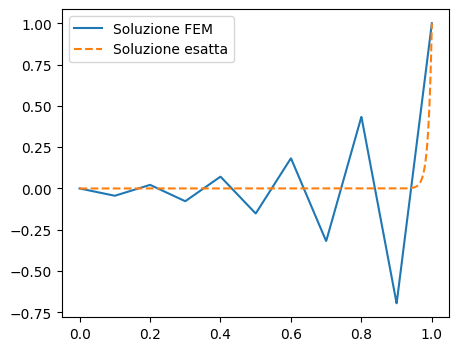

In [19]:
# soluzione esatta
uex = lambda x: (np.exp(x * beta / alpha) - 1) / (np.exp(beta / alpha) - 1)

# soluzione numerica interpolata
interp_uh = lambda x: np.interp(x, grid.nodes, uh) #interp vuole i nuovi nodi, i vecchi nodi e i valori della funzione nei nodi vecchi come argomento

# x per il plot
xplot = np.linspace(0, 1, 1000)

# rappresentazione grafica
plt.figure(figsize=(5, 4))
plt.plot(xplot, interp_uh(xplot), "-", label="Soluzione FEM")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")
plt.legend()
plt.show()

In [ ]:
#ci sono delle oscillazioni che non catturano correttamente la soluzione numerica, soprattutto in quanto la soluzione esatta
#è monotona crescente, mentre quella FEM è oscillante, crescente e decrescemte. Questo accade in quanto siamo in un caso
#di problema di trasporto dominante -> il metodo FEM soffre e non approssima correttamente la soluzione esatta, in particolare se
#h non è abbastanza piccolo.

#la soluzione esatta presenta una rapida variazione quasi in corrispondenza dell'estremo dx -> si tratta del cosiddetto strato limite, che NON viene
#colto/catturato se il valore h è NON sufficientemente piccolo.

**Commento**: siamo in un regime di trasporto dominante, in cui il coefficiente $\beta$, che rappresenta la velocità di trasporto, è molto maggiore del coefficiente diffusivo $\alpha$. In questo caso, dal punto di vista numerico, si osservano instabilità nella soluzione approssimata. In particolare, si osserva che la soluzione è costante nella maggior parte del dominio, mentre subisce una rapida variazione in corrispondenza dell'estremo destro. Questa regione in cui la soluzione varia è detta strato limite (boundary layer) ed è responsabile delle maggiori oscillazioni numeriche. La scelta del passo $h$ della griglia non è sufficientemente piccola per rappresentare lo strato limite. Esistono diversi metodi per risolvere o mitigare questo problema. Uno di questi consiste nel ridurre il passo di discretizzazione $h$, migliorando così la risoluzione numerica della soluzione. In particolare, si definisce il numero di Peclet come segue:

\begin{equation}
Pe = \frac{\beta h}{2\alpha}.
\end{equation}

Per evitare instabilità numeriche, occorre scegliere $h$ in modo tale che $Pe<1$. Con i dati del problema: $h<0.02$.

In [ ]:
#Pe < 1 -> h < 2*alpha/beta

<mark>**Esercizio 2.4**</mark></br>

Ripetere l'Esercizio 2.3, variando il valore di $h$, in modo da ottenere una soluzione numerica stabile. 

# Equazioni di diffusione-trasporto-reazione

Si consideri il seguente problema differenziale, descrivente un fenomeno di diffusione-trasporto-reazione (stazionario)

$$
\begin{cases}
(-\alpha u'+\beta u)'+\gamma u = f, & x\in(0,1)\\
u(0)=u(1)=0.
\end{cases}
$$

dove $\alpha>0,\beta\neq0,\gamma>0$ sono opportuni coefficienti. La corrispondente formulazione debole è
</br></br>
$$\alpha\int_0^1u'v'dx-\beta\int_0^1uv'dx+\gamma\int_0^1uvdx=\int_0^1fvdx.$$

In [ ]:
#FORMA DEBOLE
#a(u,v)+b(u,v)+c(u,v)=F(v)

#Forma ALGEBRICA
#AU+BU+CU=F, ove A=matrice di diffusione (simmetrica con 2 su diagonale e -1 fuori dalla diagonale), B=matrice di trasporto, C=matrice di massa
#ed è la medesima M usata precedentemente per la creazione del termine noto

<mark>**Esercizio 3.1**</mark></br>

Sia $V_h$ lo spazio elementi finiti di grado $r=1$ e passo $h=0.01$. Assemblare le matrici associate alle forme bilineari, senza imporre alcuna condizione al bordo.


In [13]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, transport, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.01
# numero elementi
Nele = int((b - a) / h)

# creazione griglia
grid=Grid(a,b,Nele)
grid.compute_geometry()

# assemblaggio matrici di diffusione, trasporto e reazione
A_diff=diffusion(grid)
A_trasp=transport(grid)
A_reac=mass(grid)


<mark>**Esercizio 3.2**</mark></br>

Sfruttando le matrici appena assemblate, risolvere numericamente l'equazione di diffusione-trasporto-reazione per $\alpha=1$, $\beta=2$ e $\gamma=3$. Si ponga $f\equiv-1$. Confrontare la soluzione ottenuta con quella esatta, sapendo l'espressione di quest'ultima è:

$$u(x)=C_1 e^{-x}+C_2e^{3x}-\frac{1}{3},$$

dove $C_2=\frac{1}{3}\frac{e-1}{e^4-1}$ e $C_1=\frac{1}{3}-C_2$.

La matrice di rigidezza totale è definita come $A = A_{\mathrm{diff}} + A_{\mathrm{trasp}} + A_{\mathrm{reaz}}$, includendo i coefficienti di diffusione, reazione e trasporto.

In [14]:
# assemblaggio termine noto
f=lambda x: -1 + 0*x
f_dofs=fun2dof(grid,f)
M=A_reac
F=M @ f_dofs

# assemblaggio matrice di rigidezza
alpha, beta, gamma = 1, 2, 3
A = alpha*A_diff+beta*A_trasp+gamma*A_reac

# gestione condizioni di Dirichlet
dirichlet_nodes = [0, -1]
dirichlet_values = [0, 0]

bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False

R = create_restriction(keep_dof)
print(R)

A0 = R @ A @ R.T
F0 = R @ (F - A @ bc_values)

# risoluzione sistema lineare
u_0 = np.linalg.solve(A0,F0)
# aggiunta condizione di Dirichlet
u = bc_values + R.T @ u_0

[[0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]]


In [15]:
e = np.exp(1)
c2 = (e - 1.0) / (e**4 - 1.0) / 3.0
c1 = 1.0 / 3.0 - c2
uex = lambda x: c1 * np.exp(-x) + c2 * np.exp(3 * x) - 1.0 / 3.0

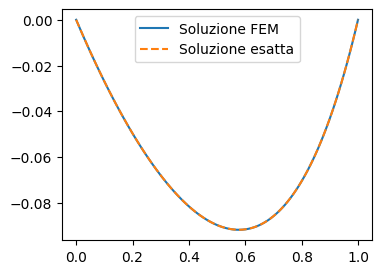

In [16]:
xplot = np.linspace(0, 1, 1000)

plt.figure(figsize=(4, 3))
plt.plot(grid.nodes, u, "-", label="Soluzione FEM")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")
plt.legend()
plt.show()

<mark>**Esercizio 3.3**</mark></br>

Provate a ripetere l'Es. 3.2 per diversi valori di $b \ge 0$. Come cambia la soluzione numerica?

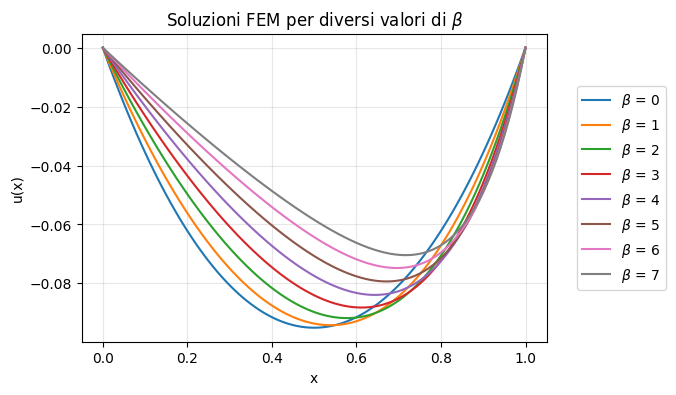

In [17]:
# tutte le soluzioni numeriche nello stesso grafico al variare di beta
plt.figure(figsize=(6, 4))

for beta in range(0,8):
    A = alpha*A_diff+beta*A_trasp+gamma*A_reac
    A_0=R@A@R.T
    rhs_0=R@(F-A@bc_values)

    # risoluzione sistema lineare
    u_0=np.linalg.solve(A_0, rhs_0)
    #aggiunta della condizione di Dirichlet
    u=bc_values+R.T@u_0
    plt.plot(grid.nodes, u, "-", label=f"$\\beta$ = {beta}")

plt.title("Soluzioni FEM per diversi valori di $\\beta$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
plt.grid(True, alpha=0.3)
plt.show()


Nel caso $\beta=0$, l'equazione va incontro esclusivamente a diffusione e reazione. La presenza del trasporto, invece, produce uno spostamento della soluzione verso destra, rendendola asimmetrica. Al crescere del trasporto, si tende ad un problema a trasporto dominante, con la creazione di uno strato limite per $x \rightarrow 1$.

**Commento**: combinando tutti gli strumenti visti nei Laboratori 10 e 11 è possibile risolvere problemi di diffusione-reazione-trasporto con condizioni di Dirichlet o Neumann. 